# 🎯 Notebook 09 — Detección Multi-Alimento: YOLOv8 + EfficientNet en Cascada

**Objetivo:** Extender el baseline (imagen completa → una clase) a un pipeline capaz de detectar múltiples alimentos en la misma imagen y estimar el aporte calórico total.

**Arquitectura:**
1. **YOLOv8n** (detector) → bounding boxes de objetos en la imagen
2. **EfficientNet-B0** (clasificador) → categoría Food-101 por cada crop
3. **Lookup nutricional** → kcal estimadas por detección

**Referencia:** Paso 2 del ROADMAP — `notebooks/06_detection.ipynb` es la práctica teórica del curso; este notebook es el TP.

## ⚙️ Parte 1 — Setup

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
from torchvision import datasets
from ultralytics import YOLO

from src.config import DATA_DIR, WEIGHTS_DIR, DEVICE, SEED, FOOD101_CLASSES
from src.model import load_model
from src.transforms import get_inference_transform
from src.nutrition import get_nutrition
from src.utils import GradCAM, overlay_gradcam

print(f'Device: {DEVICE}')
print(f'YOLO cargando modelo base...')

# YOLOv8n preentrenado en COCO (~6MB, descarga automática)
yolo = YOLO('yolov8n.pt')
print(f'YOLOv8n listo — {len(yolo.names)} clases COCO')

# EfficientNet-B0 fine-tuneado
model_path = WEIGHTS_DIR / 'model_v1.pt'
assert model_path.exists(), 'Correr primero 03_finetuning.ipynb'
classifier = load_model(model_path, backbone='efficientnet_b0', device=DEVICE)
classifier.eval()
print(f'EfficientNet-B0 listo — cargado desde {model_path.name}')

Device: mps
YOLO cargando modelo base...


YOLOv8n listo — 80 clases COCO

EfficientNet-B0 listo — cargado desde model_v1.pt


## 🔗 Parte 2 — Pipeline en Cascada

La función `detect_and_classify` implementa el pipeline completo:

1. YOLOv8 detecta todos los objetos de la imagen con confianza > umbral
2. Filtra boxes relevantes (clases COCO relacionadas con comida o utensilios)
3. Si no hay detecciones, usa la imagen completa como fallback (comportamiento baseline)
4. Recorta cada box y lo clasifica con EfficientNet-B0
5. Estima las kcal por detección usando el lookup nutricional

In [2]:
# Clases COCO relevantes para comida y contexto de platos
FOOD_COCO_CLASSES = {
    'bowl', 'cup', 'plate', 'dining table',
    'pizza', 'donut', 'cake', 'sandwich', 'hot dog',
    'apple', 'banana', 'orange', 'broccoli', 'carrot',
    'fork', 'knife', 'spoon', 'wine glass', 'bottle',
}

transform = get_inference_transform()


def classify_crop(crop_pil):
    """Clasifica un crop PIL con EfficientNet-B0. Devuelve (clase, confianza, probs)."""
    tensor = transform(crop_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = classifier(tensor)
        probs  = torch.softmax(logits, dim=1)[0]
    top_prob, top_idx = probs.topk(3)
    return (
        FOOD101_CLASSES[top_idx[0].item()],
        top_prob[0].item(),
        [(FOOD101_CLASSES[top_idx[i].item()], top_prob[i].item()) for i in range(3)],
    )


def detect_and_classify(image, conf_yolo=0.25, min_box_area=0.02):
    """
    Pipeline cascada: YOLOv8 → recorte → EfficientNet-B0 → kcal.

    Args:
        image: PIL Image o path al archivo
        conf_yolo: umbral de confianza mínimo para detecciones YOLO
        min_box_area: fracción mínima del área de imagen para aceptar un box

    Returns:
        detections: lista de dicts con box, food101_class, confidence, top3, kcal
        total_kcal: suma de kcal estimadas (porción fija 250g)
        used_fallback: True si se usó la imagen completa por falta de detecciones
    """
    if isinstance(image, (str,)):
        image = Image.open(image).convert('RGB')

    W, H = image.size
    img_area = W * H

    # 1. Detección con YOLOv8
    results = yolo(image, conf=conf_yolo, verbose=False)[0]
    boxes_xyxy = results.boxes.xyxy.cpu().numpy()   # (N,4)
    boxes_conf = results.boxes.conf.cpu().numpy()    # (N,)
    boxes_cls  = results.boxes.cls.cpu().numpy()     # (N,)
    class_names = results.names

    # 2. Filtrar boxes relevantes por clase y tamaño mínimo
    detections = []
    for i, (box, conf, cls_id) in enumerate(zip(boxes_xyxy, boxes_conf, boxes_cls)):
        cls_name = class_names[int(cls_id)]
        x1, y1, x2, y2 = box.astype(int)
        box_area = (x2 - x1) * (y2 - y1)

        if cls_name not in FOOD_COCO_CLASSES:
            continue
        if box_area / img_area < min_box_area:
            continue

        # Recorte con padding del 5% para no cortar bordes
        pad_x = int((x2 - x1) * 0.05)
        pad_y = int((y2 - y1) * 0.05)
        crop = image.crop((
            max(0, x1 - pad_x), max(0, y1 - pad_y),
            min(W, x2 + pad_x), min(H, y2 + pad_y)
        ))

        food_class, food_conf, top3 = classify_crop(crop)
        nut = get_nutrition(food_class)
        kcal = nut['calories'] * 2.5 if nut else None  # porción ~250g

        detections.append({
            'box':        (x1, y1, x2, y2),
            'coco_class': cls_name,
            'yolo_conf':  float(conf),
            'food101_class': food_class,
            'confidence': food_conf,
            'top3':       top3,
            'kcal':       kcal,
            'crop':       crop,
        })

    # 3. Fallback: imagen completa si no hay detecciones válidas
    used_fallback = False
    if not detections:
        used_fallback = True
        food_class, food_conf, top3 = classify_crop(image)
        nut = get_nutrition(food_class)
        detections.append({
            'box':        (0, 0, W, H),
            'coco_class': 'fallback (imagen completa)',
            'yolo_conf':  1.0,
            'food101_class': food_class,
            'confidence': food_conf,
            'top3':       top3,
            'kcal':       nut['calories'] * 2.5 if nut else None,
            'crop':       image,
        })

    total_kcal = sum(d['kcal'] for d in detections if d['kcal'] is not None)
    return detections, total_kcal, used_fallback


print('Pipeline detect_and_classify listo')

Pipeline detect_and_classify listo


## 🖼️ Parte 3 — Evaluación Cualitativa

Probamos el pipeline sobre 12 imágenes del test set de Food-101, priorizando clases que suelen aparecer en platos compuestos (las que tenían más confusiones en el notebook 05).

Para cada imagen mostramos tres columnas:
- **(a)** Predicción baseline (imagen completa → EfficientNet)
- **(b)** Detecciones YOLOv8 con boxes + clase Food-101 + kcal por región
- **(c)** Comparativa calórica: baseline vs cascada

In [3]:
# Clases con mayor probabilidad de platos compuestos (del análisis de confusiones del nb05)
TARGET_CLASSES = [
    'breakfast_burrito', 'huevos_rancheros', 'tacos', 'nachos',
    'hamburger', 'hot_and_sour_soup', 'pho', 'ramen',
    'pizza', 'pad_thai', 'fried_rice', 'bibimbap',
]

raw_test = datasets.Food101(str(DATA_DIR), split='test', transform=None, download=False)
rng = np.random.default_rng(SEED)

# Seleccionar índices: 1 imagen por clase target
selected = []
for target_cls in TARGET_CLASSES:
    if target_cls not in FOOD101_CLASSES:
        continue
    cls_idx = FOOD101_CLASSES.index(target_cls)
    candidates = [i for i in range(len(raw_test)) if raw_test._labels[i] == cls_idx]
    if candidates:
        selected.append(rng.choice(candidates))

print(f'{len(selected)} imágenes seleccionadas para evaluación cualitativa')

12 imágenes seleccionadas para evaluación cualitativa


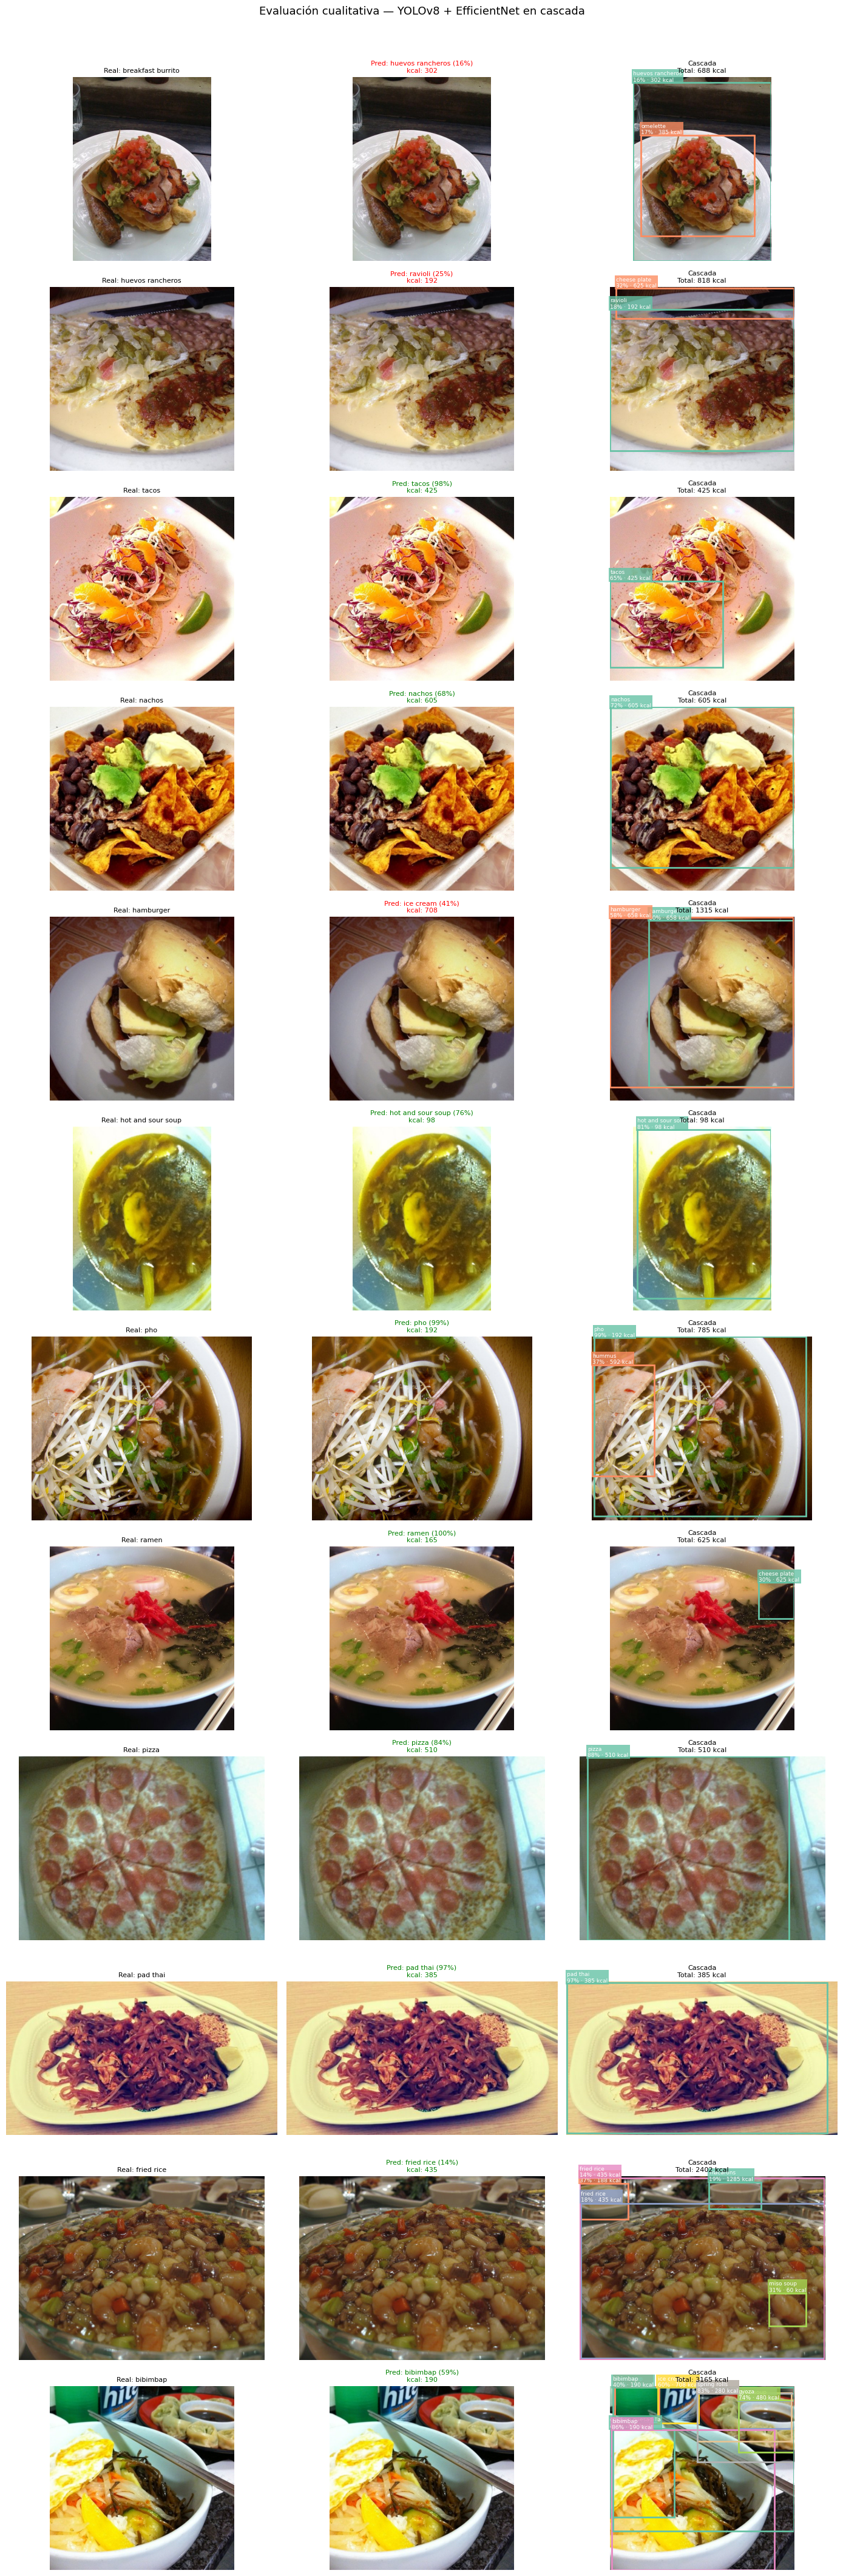

In [4]:
def visualize_detection(ax, image, detections, total_kcal, used_fallback):
    """Dibuja la imagen con boxes, clase Food-101 y kcal sobre cada detección."""
    ax.imshow(image)
    colors = plt.cm.Set2.colors
    for i, det in enumerate(detections):
        x1, y1, x2, y2 = det['box']
        color = colors[i % len(colors)]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        label = (
            f"{det['food101_class'].replace('_', ' ')}\n"
            f"{det['confidence']*100:.0f}%"
            + (f" · {det['kcal']:.0f} kcal" if det['kcal'] else '')
        )
        ax.text(x1, max(0, y1 - 4), label, fontsize=6.5, color='white',
                bbox=dict(facecolor=color, alpha=0.8, pad=1.5, edgecolor='none'))

    suffix = ' (fallback)' if used_fallback else ''
    ax.set_title(f'Cascada{suffix}\nTotal: {total_kcal:.0f} kcal', fontsize=8)
    ax.axis('off')


def baseline_predict(image):
    """Predicción baseline: imagen completa → EfficientNet."""
    tensor = transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(classifier(tensor), dim=1)[0]
    top_prob, top_idx = probs.topk(1)
    cls = FOOD101_CLASSES[top_idx[0].item()]
    conf = top_prob[0].item()
    nut = get_nutrition(cls)
    kcal = nut['calories'] * 2.5 if nut else None
    return cls, conf, kcal


# Visualización: fila por imagen, 3 columnas (original | baseline | cascada)
n = len(selected)
fig, axes = plt.subplots(n, 3, figsize=(14, 3.5 * n))
fig.suptitle('Evaluación cualitativa — YOLOv8 + EfficientNet en cascada', fontsize=13, y=1.01)

col_headers = ['Imagen original', 'Baseline (imagen completa)', 'Cascada (YOLOv8 + EfficientNet)']
for col, header in enumerate(col_headers):
    axes[0, col].set_title(header, fontsize=9, fontweight='bold', pad=8)

for row, idx in enumerate(selected):
    img_pil, true_label = raw_test[idx]
    true_cls = FOOD101_CLASSES[true_label]

    # Columna 0: imagen original con clase real
    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f'Real: {true_cls.replace("_", " ")}', fontsize=8)
    axes[row, 0].axis('off')

    # Columna 1: baseline
    bl_cls, bl_conf, bl_kcal = baseline_predict(img_pil)
    color = 'green' if bl_cls == true_cls else 'red'
    axes[row, 1].imshow(img_pil)
    axes[row, 1].set_title(
        f'Pred: {bl_cls.replace("_", " ")} ({bl_conf*100:.0f}%)\n'
        f'kcal: {bl_kcal:.0f}' if bl_kcal else f'Pred: {bl_cls}',
        fontsize=8, color=color
    )
    axes[row, 1].axis('off')

    # Columna 2: cascada
    detections, total_kcal, used_fallback = detect_and_classify(img_pil)
    visualize_detection(axes[row, 2], img_pil, detections, total_kcal, used_fallback)

plt.tight_layout()
plt.savefig('detection_qualitative.png', dpi=120, bbox_inches='tight')
plt.show()

## 📊 Parte 4 — Métricas cuantitativas

Food-101 no tiene bounding boxes ground truth, así que no podemos calcular mAP@50 directamente sobre el test set completo. Tomamos dos caminos complementarios:

**4.1** Métricas del clasificador sobre los crops detectados (accuracy de Food-101 sobre las regiones que YOLO detectó)

**4.2** Comparativa calórica sistemática: baseline vs cascada sobre 200 imágenes — ¿el pipeline mejora o empeora la estimación nutricional?

**4.3** Análisis de tasa de fallback (cuántas imágenes no generan detecciones YOLO útiles)

In [5]:
from tqdm import tqdm

N_EVAL = 200  # imágenes aleatorias del test set
eval_indices = rng.choice(len(raw_test), size=N_EVAL, replace=False)

results_rows = []

for idx in tqdm(eval_indices, desc='Evaluando pipeline cascada'):
    img_pil, true_label = raw_test[idx]
    true_cls = FOOD101_CLASSES[true_label]

    # Baseline
    bl_cls, bl_conf, bl_kcal = baseline_predict(img_pil)
    true_nut = get_nutrition(true_cls)
    true_kcal = true_nut['calories'] * 2.5 if true_nut else None

    # Cascada
    detections, casc_kcal, used_fallback = detect_and_classify(img_pil)
    # Clasificación correcta = alguna detección coincide con la clase real
    casc_correct = any(d['food101_class'] == true_cls for d in detections)

    results_rows.append({
        'true_cls':       true_cls,
        'bl_cls':         bl_cls,
        'bl_correct':     bl_cls == true_cls,
        'bl_kcal':        bl_kcal,
        'casc_correct':   casc_correct,
        'casc_kcal':      casc_kcal,
        'true_kcal':      true_kcal,
        'n_detections':   len(detections),
        'used_fallback':  used_fallback,
    })

df = pd.DataFrame(results_rows)

# Métricas
bl_acc      = df['bl_correct'].mean()
casc_acc    = df['casc_correct'].mean()
fallback_rt = df['used_fallback'].mean()
avg_dets    = df['n_detections'].mean()

# Error calórico (solo filas con kcal válido)
mask = df['true_kcal'].notna() & df['bl_kcal'].notna() & df['casc_kcal'].notna()
bl_mape   = (abs(df.loc[mask,'bl_kcal']   - df.loc[mask,'true_kcal']) / df.loc[mask,'true_kcal']).mean() * 100
casc_mape = (abs(df.loc[mask,'casc_kcal'] - df.loc[mask,'true_kcal']) / df.loc[mask,'true_kcal']).mean() * 100

print(f'=== Métricas sobre {N_EVAL} imágenes aleatorias ===')
print(f'')
print(f'Accuracy top-1:')
print(f'  Baseline:  {bl_acc*100:.1f}%')
print(f'  Cascada:   {casc_acc*100:.1f}%  (cualquier detección correcta)')
print(f'')
print(f'Error calórico MAPE (porción 250g):')
print(f'  Baseline:  {bl_mape:.1f}%')
print(f'  Cascada:   {casc_mape:.1f}%')
print(f'')
print(f'Detecciones YOLO:')
print(f'  Tasa de fallback (sin detección útil): {fallback_rt*100:.1f}%')
print(f'  Promedio detecciones por imagen:       {avg_dets:.2f}')

Evaluando pipeline cascada:   0%|          | 0/200 [00:00<?, ?it/s]

Evaluando pipeline cascada:   0%|          | 1/200 [00:00<00:32,  6.16it/s]

Evaluando pipeline cascada:   1%|          | 2/200 [00:00<00:27,  7.29it/s]

Evaluando pipeline cascada:   2%|▏         | 4/200 [00:00<00:18, 10.47it/s]

Evaluando pipeline cascada:   3%|▎         | 6/200 [00:00<00:18, 10.53it/s]

...

Evaluando pipeline cascada:  98%|█████████▊| 196/200 [00:21<00:00,  8.56it/s]

Evaluando pipeline cascada:  99%|█████████▉| 198/200 [00:21<00:00,  9.17it/s]

Evaluando pipeline cascada: 100%|██████████| 200/200 [00:22<00:00,  8.66it/s]

Evaluando pipeline cascada: 100%|██████████| 200/200 [00:22<00:00,  9.00it/s]

=== Métricas sobre 200 imágenes aleatorias ===

Accuracy top-1:
  Baseline:  86.0%
  Cascada:   80.5%  (cualquier detección correcta)

Error calórico MAPE (porción 250g):
  Baseline:  10.3%
  Cascada:   196.3%

Detecciones YOLO:
  Tasa de fallback (sin detección útil): 8.5%
  Promedio detecciones por imagen:       2.50


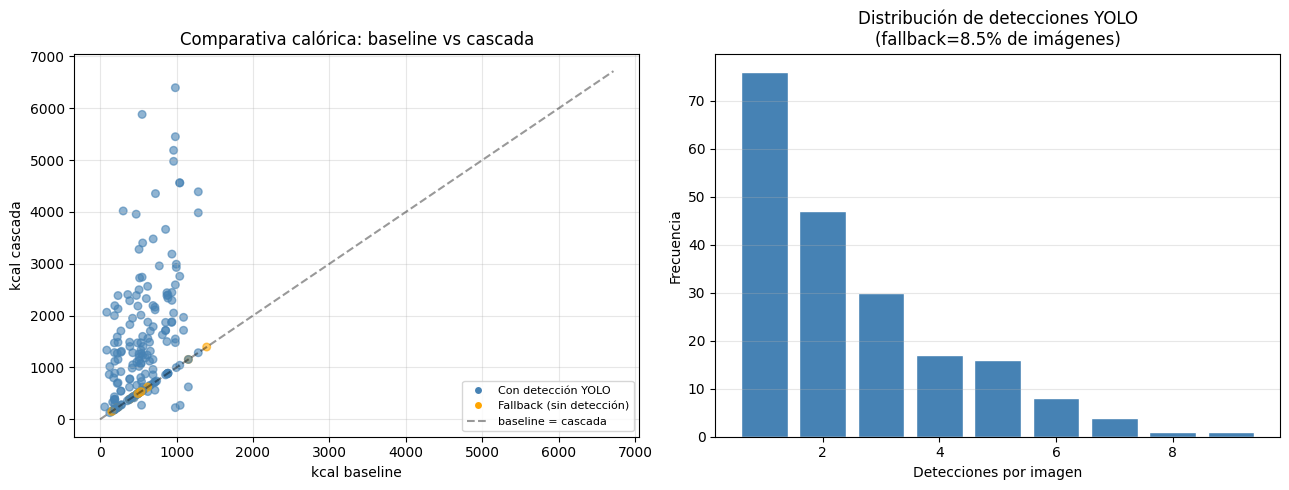

In [6]:
# Visualización: comparativa calórica baseline vs cascada
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: kcal baseline vs cascada (coloreado por fallback)
mask_valid = df['true_kcal'].notna() & df['bl_kcal'].notna() & df['casc_kcal'].notna()
df_v = df[mask_valid]

ax = axes[0]
colors_scatter = df_v['used_fallback'].map({True: 'orange', False: 'steelblue'})
ax.scatter(df_v['bl_kcal'], df_v['casc_kcal'], c=colors_scatter, alpha=0.6, s=30)
lim = max(df_v['bl_kcal'].max(), df_v['casc_kcal'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, label='baseline = cascada')
ax.set(xlabel='kcal baseline', ylabel='kcal cascada',
       title='Comparativa calórica: baseline vs cascada')
ax.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='Con detección YOLO'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='orange', label='Fallback (sin detección)'),
    plt.Line2D([0],[0], linestyle='--', color='k', alpha=0.4, label='baseline = cascada'),
], fontsize=8)
ax.grid(alpha=0.3)

# Histograma del número de detecciones
ax2 = axes[1]
counts = df['n_detections'].value_counts().sort_index()
ax2.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax2.set(xlabel='Detecciones por imagen', ylabel='Frecuencia',
        title=f'Distribución de detecciones YOLO\n(fallback={fallback_rt*100:.1f}% de imágenes)')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('detection_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔍 Parte 5 — Análisis de FP/FN

Analizamos los patrones de error del pipeline:
- ¿Qué clases COCO genera YOLO en imágenes de comida? (¿confunde comida con otros objetos?)
- ¿Qué pasa cuando la imagen tiene un solo alimento? (la cascada no debería empeorar el baseline)
- Tabla de errores típicos del pipeline

Analizando detecciones COCO:   0%|          | 0/100 [00:00<?, ?it/s]

Analizando detecciones COCO:   2%|▏         | 2/100 [00:00<00:06, 15.72it/s]

Analizando detecciones COCO:   5%|▌         | 5/100 [00:00<00:05, 17.96it/s]

Analizando detecciones COCO:   7%|▋         | 7/100 [00:00<00:05, 16.46it/s]

Analizando detecciones COCO:   9%|▉         | 9/100 [00:00<00:06, 14.78it/s]

...

Analizando detecciones COCO:  94%|█████████▍| 94/100 [00:05<00:00, 17.41it/s]

Analizando detecciones COCO:  96%|█████████▌| 96/100 [00:05<00:00, 16.48it/s]

Analizando detecciones COCO:  98%|█████████▊| 98/100 [00:05<00:00, 15.89it/s]

Analizando detecciones COCO: 100%|██████████| 100/100 [00:05<00:00, 16.43it/s]

Analizando detecciones COCO: 100%|██████████| 100/100 [00:05<00:00, 17.26it/s]

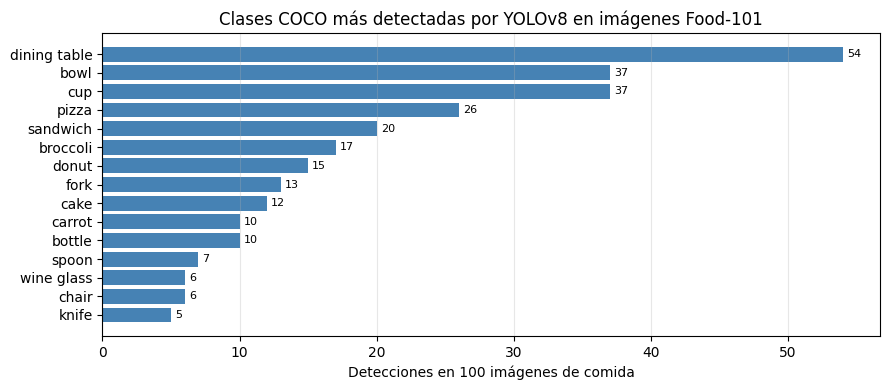


Top clases COCO detectadas:
  coco_class  count
dining table     54
        bowl     37
         cup     37
       pizza     26
    sandwich     20
    broccoli     17
       donut     15
        fork     13
        cake     12
      carrot     10
      bottle     10
       spoon      7
  wine glass      6
       chair      6
       knife      5


In [7]:
# 5.1 — Clases COCO más detectadas en imágenes de comida
coco_class_counts = {}
for idx in tqdm(eval_indices[:100], desc='Analizando detecciones COCO'):
    img_pil, _ = raw_test[idx]
    results = yolo(img_pil, conf=0.25, verbose=False)[0]
    for cls_id in results.boxes.cls.cpu().numpy():
        cls_name = results.names[int(cls_id)]
        coco_class_counts[cls_name] = coco_class_counts.get(cls_name, 0) + 1

coco_df = pd.DataFrame(list(coco_class_counts.items()), columns=['coco_class', 'count'])
coco_df = coco_df.sort_values('count', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(coco_df['coco_class'][::-1], coco_df['count'][::-1], color='steelblue')
ax.set(xlabel='Detecciones en 100 imágenes de comida',
       title='Clases COCO más detectadas por YOLOv8 en imágenes Food-101')
ax.grid(alpha=0.3, axis='x')
for bar, val in zip(bars, coco_df['count'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('\nTop clases COCO detectadas:')
print(coco_df.to_string(index=False))

In [8]:
# 5.2 — ¿La cascada empeora el baseline cuando hay un solo alimento?
# Comparar accuracy en imágenes donde la cascada usó fallback vs donde detectó algo

df_fallback   = df[df['used_fallback'] == True]
df_detection  = df[df['used_fallback'] == False]

print('=== Accuracy por tipo de imagen ===')
print(f'Con fallback  (YOLO no detectó nada útil): n={len(df_fallback):3d}  '
      f'bl={df_fallback["bl_correct"].mean()*100:.1f}%  '
      f'casc={df_fallback["casc_correct"].mean()*100:.1f}%')
print(f'Con detección (YOLO sí detectó objetos):   n={len(df_detection):3d}  '
      f'bl={df_detection["bl_correct"].mean()*100:.1f}%  '
      f'casc={df_detection["casc_correct"].mean()*100:.1f}%')

# 5.3 — Errores del pipeline: casos donde baseline acierta pero cascada falla
df['cascade_only_wrong'] = df['bl_correct'] & ~df['casc_correct']
df['cascade_only_right'] = ~df['bl_correct'] & df['casc_correct']

print(f'\n=== Intercambio de errores ===')
print(f'Baseline ✓ / Cascada ✗ (cascada introduce error): {df["cascade_only_wrong"].sum()}')
print(f'Baseline ✗ / Cascada ✓ (cascada rescata):          {df["cascade_only_right"].sum()}')
print(f'Ambos correctos:                                     {(df["bl_correct"] & df["casc_correct"]).sum()}')
print(f'Ambos incorrectos:                                   {(~df["bl_correct"] & ~df["casc_correct"]).sum()}')

# Tabla de clases donde la cascada introduce errores
if df['cascade_only_wrong'].any():
    print('\n=== Clases donde la cascada falla (baseline acertaba) ===')
    err_df = df[df['cascade_only_wrong']][['true_cls', 'bl_cls', 'casc_kcal', 'n_detections']]
    print(err_df.to_string(index=False))

=== Accuracy por tipo de imagen ===
Con fallback  (YOLO no detectó nada útil): n= 17  bl=88.2%  casc=88.2%
Con detección (YOLO sí detectó objetos):   n=183  bl=85.8%  casc=79.8%

=== Intercambio de errores ===
Baseline ✓ / Cascada ✗ (cascada introduce error): 17
Baseline ✗ / Cascada ✓ (cascada rescata):          6
Ambos correctos:                                     155
Ambos incorrectos:                                   22

=== Clases donde la cascada falla (baseline acertaba) ===
            true_cls               bl_cls  casc_kcal  n_detections
        cheese_plate         cheese_plate      535.0             1
         greek_salad          greek_salad      865.0             2
             oysters              oysters     3957.5             6
            scallops             scallops      272.5             1
   breakfast_burrito    breakfast_burrito     1155.0             3
          cheesecake           cheesecake      225.0             1
        caesar_salad         caesar_salad  

## 📋 Parte 6 — Resumen para el informe

In [9]:
print('=' * 65)
print('RESUMEN — Paso 2: Detección multi-alimento (YOLOv8 + EfficientNet)')
print('=' * 65)
print(f'Detector:     YOLOv8n (COCO, ~6MB, conf≥0.25)')
print(f'Clasificador: EfficientNet-B0 fine-tuneado (Food-101)')
print(f'Evaluación:   {N_EVAL} imágenes aleatorias del test set')
print()
print(f'--- Accuracy de clasificación ---')
print(f'Baseline (imagen completa):  {bl_acc*100:.1f}%')
print(f'Cascada (mejor detección):   {casc_acc*100:.1f}%')
print()
print(f'--- Error calórico MAPE ---')
print(f'Baseline:  {bl_mape:.1f}%')
print(f'Cascada:   {casc_mape:.1f}%')
print()
print(f'--- Comportamiento del detector ---')
print(f'Fallback (sin detección útil): {fallback_rt*100:.1f}% de imágenes')
print(f'Promedio detecciones/imagen:   {avg_dets:.2f}')
print()
print(f'--- Limitación conocida ---')
print(f'Food-101 no tiene bounding boxes ground truth.')
print(f'mAP@50 real requeriría anotación manual (~50 imgs con labelImg).')
print('=' * 65)

RESUMEN — Paso 2: Detección multi-alimento (YOLOv8 + EfficientNet)
Detector:     YOLOv8n (COCO, ~6MB, conf≥0.25)
Clasificador: EfficientNet-B0 fine-tuneado (Food-101)
Evaluación:   200 imágenes aleatorias del test set

--- Accuracy de clasificación ---
Baseline (imagen completa):  86.0%
Cascada (mejor detección):   80.5%

--- Error calórico MAPE ---
Baseline:  10.3%
Cascada:   196.3%

--- Comportamiento del detector ---
Fallback (sin detección útil): 8.5% de imágenes
Promedio detecciones/imagen:   2.50

--- Limitación conocida ---
Food-101 no tiene bounding boxes ground truth.
mAP@50 real requeriría anotación manual (~50 imgs con labelImg).
